In [4]:
# ─── 0. COMPATIBILITY PATCH (numpy version mismatch) ─────────────────────────
import sys
import numpy
import numpy.core
sys.modules['numpy._core'] = numpy.core
sys.modules['numpy._core.numeric'] = numpy.core.numeric



In [3]:
import pickle as pkl


In [5]:
# ─── 0. COMPATIBILITY PATCH (numpy version mismatch) ─────────────────────────
import sys
import numpy
import numpy.core
sys.modules['numpy._core'] = numpy.core
sys.modules['numpy._core.numeric'] = numpy.core.numeric

# ─── 1. IMPORTS ───────────────────────────────────────────────────────────────
import os
import numpy as np
import tensorflow as tf
import pickle as pkl
from sklearn.cross_decomposition import CCA
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from scipy.stats import pearsonr

from deepmreye.util import data_generator, model_opts
from deepmreye import train

# ─── 2. HELPER FUNCTIONS ──────────────────────────────────────────────────────

def get_divided_paths(file_list, eye="left"):
    """Convert original .npz paths to left/right divided paths."""
    if eye not in ["left", "right"]:
        raise ValueError('eye must be "left" or "right"')
    divided_paths = []
    for orig_path in file_list:
        parts = orig_path.split(os.sep)
        dataset_folder = parts[5]
        filename = os.path.basename(orig_path)
        base = filename.replace(".npz", "")
        divided_path = os.path.join(
            f"/mnt/compneuro/deepmreye_finetuning/processed_data_separate_eyes/{eye}",
            dataset_folder,
            f"{base}_{eye}.npz"
        )
        divided_paths.append(divided_path)
    return divided_paths


def extract_features(npz_path, extractor):
    """Extract bottleneck features for all TRs in a single npz file."""
    f = np.load(npz_path, allow_pickle=True)
    data_keys = sorted([k for k in f.keys() if k.startswith('data_')])
    features = []
    for dk in data_keys:
        tr = f[dk][np.newaxis, ..., np.newaxis]
        features.append(extractor(tr, training=False).numpy()[0])
    return np.array(features)  # (n_TRs, 4608)


def cca_crossval(feats_left, feats_right, n_pre=10, n_splits=10):
    """Shuffle-split cross-validated CCA between left and right eye features."""
    n_trs = len(feats_left)
    rs_dim1, rs_dim2 = [], []

    for seed in range(n_splits):
        rng = np.random.RandomState(seed)
        idx = rng.permutation(n_trs)
        train_idx = idx[:n_trs // 2]
        test_idx  = idx[n_trs // 2:]

        scaler_l = StandardScaler().fit(feats_left[train_idx])
        scaler_r = StandardScaler().fit(feats_right[train_idx])
        pca_l = PCA(n_components=n_pre).fit(scaler_l.transform(feats_left[train_idx]))
        pca_r = PCA(n_components=n_pre).fit(scaler_r.transform(feats_right[train_idx]))

        L_tr = pca_l.transform(scaler_l.transform(feats_left[train_idx]))
        R_tr = pca_r.transform(scaler_r.transform(feats_right[train_idx]))
        L_te = pca_l.transform(scaler_l.transform(feats_left[test_idx]))
        R_te = pca_r.transform(scaler_r.transform(feats_right[test_idx]))

        cca = CCA(n_components=2).fit(L_tr, R_tr)
        L_cca, R_cca = cca.transform(L_te, R_te)

        r1, _ = pearsonr(L_cca[:, 0], R_cca[:, 0])
        r2, _ = pearsonr(L_cca[:, 1], R_cca[:, 1])
        rs_dim1.append(r1)
        rs_dim2.append(r2)

    return np.mean(rs_dim1), np.std(rs_dim1), np.mean(rs_dim2), np.std(rs_dim2)

# ─── 3. TRAIN/TEST SPLIT ──────────────────────────────────────────────────────

all_files = []
for root, dirs, files in os.walk('/mnt/compneuro/deepmreye_finetuning/processed_data/'):
    if 'dataset7_resting_state' in root:
        continue
    for name in files:
        all_files.append(os.path.join(root, name))

datasets = {}
for f in all_files:
    dataset_name = os.path.basename(os.path.dirname(f))
    datasets.setdefault(dataset_name, []).append(f)

train_list, test_list = [], []
for dataset_name, files in datasets.items():
    files = sorted(files)
    np.random.shuffle(files)
    split_idx = int(0.8 * len(files))
    train_list.extend(files[:split_idx])
    test_list.extend(files[split_idx:])

print(f"Total train: {len(train_list)}  |  Total test: {len(test_list)}")

with open("train_list.txt", "w") as f:
    f.writelines(f"{p}\n" for p in train_list)
with open("test_list.txt", "w") as f:
    f.writelines(f"{p}\n" for p in test_list)

test_list_left   = get_divided_paths(test_list,  eye="left")
train_list_left  = get_divided_paths(train_list, eye="left")
test_list_right  = get_divided_paths(test_list,  eye="right")
train_list_right = get_divided_paths(train_list, eye="right")

# ─── 4. LOAD MODELS ───────────────────────────────────────────────────────────

opts = model_opts.get_opts()

generators_left = data_generator.create_generators(test_list_left, test_list_left)
generators_left = (*generators_left, test_list_left, test_list_left)
(_, model_inference_left) = train.train_model(
    dataset="prediction_on_left_eye",
    generators=generators_left,
    opts=opts,
    return_untrained=True
)
model_inference_left.load_weights('/mnt/compneuro/plgkoba/modelinference_left_eye.h5')
print("Left model loaded — input:", model_inference_left.input_shape)

generators_right = data_generator.create_generators(test_list_right, test_list_right)
generators_right = (*generators_right, test_list_right, test_list_right)
(_, model_inference_right) = train.train_model(
    dataset="prediction_on_right_eye",
    generators=generators_right,
    opts=opts,
    return_untrained=True
)
model_inference_right.load_weights('/mnt/compneuro/plgkoba/modelinference_right_eye.h5')  # ← fixed bug
print("Right model loaded — input:", model_inference_right.input_shape)

# ─── 5. BUILD FEATURE EXTRACTORS ─────────────────────────────────────────────

feature_extractor_left = tf.keras.Model(
    inputs=model_inference_left.input,
    outputs=model_inference_left.get_layer('flatten').output
)
feature_extractor_right = tf.keras.Model(
    inputs=model_inference_right.input,
    outputs=model_inference_right.get_layer('flatten').output
)
feature_extractor_left.trainable  = False
feature_extractor_right.trainable = False
print("Bottleneck shape:", feature_extractor_left.output_shape)  # → (None, 4608)

# ─── 6. LOAD CLINICAL DATA ────────────────────────────────────────────────────

with open('/mnt/compneuro/stroke_clinical_and_neural_data_with_lesion_disconnectome.pkl', 'rb') as f:
    stroke_csv = pkl.load(f)

print("Clinical data loaded:", stroke_csv.shape)
print(stroke_csv.columns.tolist())

Total train: 210  |  Total test: 54
Training set (/mnt/compneuro/deepmreye_finetuning/processed_data_separate_eyes/left/dataset1_guided_fixations) contains 54 subjects: 
['sub-NDARDD854GF8_left', 'sub-NDARDY150ZP9_left', 'sub-NDARAT358XM9_left',
 'sub-NDARJG298YVA_left', 'sub-NDAREK575JNM_left', 'sub-NDARRB901DWV_left',
 'sub-NDAREM731BYM_left', 'sub-NDARYB392JWP_left', 'sub-NDARGE536BGD_left',
 'sub-NDARAC495TJ2_left', 'sub-NDARAA948VFH_left', 'sub-NDARFE299MWU_left',
 'sub-NDARFM749LF3_left', 'sub-NDARGJ395FKP_left', 'sub-NDARFV780ABD_left',
 'sub-NDARBT607PZL_left', 'sub-NDARHG188YE9_left', 'sub-NDARDE877RFH_left',
 'sub-NDARGK041TPB_left', 'sub-NDAREY778CR9_left', 'sub-NDARYM334BZ5_left',
 'sub-NDARDL511UND_left', 'sub-NDARED628HMQ_left', 'sub-NDARVP285RXV_left',
 'sub-NDARAH503YG1_left', 'sub-NDARGV781AMW_left', 'sub-NDARGF367KVL_left',
 'sub-NDARRL426AD5_left', 'sub-NDARRM073JKA_left', 'sub-NDARPE752VYE_left',
 'sub-NDARDN393BJH_left', 'sub-NDARBN365EV3_left', 'sub-NDARFB969EMV_l

2026-03-26 08:23:57.078068: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-03-26 08:23:57.254088: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-03-26 08:23:57.257643: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-

Left model loaded — input: (None, 24, 29, 18, 1)
Training set (/mnt/compneuro/deepmreye_finetuning/processed_data_separate_eyes/right/dataset1_guided_fixations) contains 54 subjects: 
['sub-NDARDD854GF8_right', 'sub-NDARDY150ZP9_right', 'sub-NDARAT358XM9_right',
 'sub-NDARJG298YVA_right', 'sub-NDAREK575JNM_right', 'sub-NDARRB901DWV_right',
 'sub-NDAREM731BYM_right', 'sub-NDARYB392JWP_right', 'sub-NDARGE536BGD_right',
 'sub-NDARAC495TJ2_right', 'sub-NDARAA948VFH_right', 'sub-NDARFE299MWU_right',
 'sub-NDARFM749LF3_right', 'sub-NDARGJ395FKP_right', 'sub-NDARFV780ABD_right',
 'sub-NDARBT607PZL_right', 'sub-NDARHG188YE9_right', 'sub-NDARDE877RFH_right',
 'sub-NDARGK041TPB_right', 'sub-NDAREY778CR9_right', 'sub-NDARYM334BZ5_right',
 'sub-NDARDL511UND_right', 'sub-NDARED628HMQ_right', 'sub-NDARVP285RXV_right',
 'sub-NDARAH503YG1_right', 'sub-NDARGV781AMW_right', 'sub-NDARGF367KVL_right',
 'sub-NDARRL426AD5_right', 'sub-NDARRM073JKA_right', 'sub-NDARPE752VYE_right',
 'sub-NDARDN393BJH_right',

In [6]:
pwd

'/mnt/compneuro/deepmreye_finetuning/Cemal'

In [7]:
os.listdir('/mnt/compneuro/deepmreye_finetuning/stroke_nifti/')

['sub-CON001',
 'sub-CON002',
 'sub-CON003',
 'sub-CON004',
 'sub-CON005',
 'sub-CON006',
 'sub-CON007',
 'sub-CON008',
 'sub-CON009',
 'sub-CON010',
 'sub-CON011',
 'sub-CON012',
 'sub-CON013',
 'sub-CON014',
 'sub-CON016',
 'sub-CON017',
 'sub-CON019',
 'sub-CON021',
 'sub-CON022',
 'sub-CON023',
 'sub-CON024',
 'sub-CON025',
 'sub-CON026',
 'sub-CON027',
 'sub-CON028',
 'sub-CON029',
 'sub-CON030',
 'sub-CON031',
 'sub-CON032',
 'sub-CON033',
 'sub-CON034',
 'sub-CON035',
 'sub-CON036',
 'sub-PAT024',
 'sub-PAT026',
 'sub-PAT027',
 'sub-PAT028',
 'sub-PAT029',
 'sub-PAT030',
 'sub-PAT031',
 'sub-PAT032',
 'sub-PAT033',
 'sub-PAT034',
 'sub-PAT035',
 'sub-PAT036',
 'sub-PAT037',
 'sub-PAT038',
 'sub-PAT039',
 'sub-PAT040',
 'sub-PAT041',
 'sub-PAT043',
 'sub-PAT044',
 'sub-PAT045',
 'sub-PAT046',
 'sub-PAT047',
 'sub-PAT048',
 'sub-PAT049',
 'sub-PAT050',
 'sub-PAT051',
 'sub-PAT052',
 'sub-PAT053',
 'sub-PAT054',
 'sub-PAT055',
 'sub-PAT056',
 'sub-PAT057',
 'sub-PAT058',
 'sub-PAT0

In [26]:
stroke_csv=stroke_csv.drop(columns=["PCA_left","PCA_right"])

In [27]:
stroke_csv.columns.values

array(['ID', 'Session', 'Run', 'Eyes', 'corrmats', 'gradient_corrmat',
       'lambda_corrmats', 'mean_corrmats', 'gradient_corrmat_mean',
       'lambda_corrmats_mean', 'corrmats_corrected',
       'gradient_corrmat_corrected', 'mean_corrmats_corrected',
       'gradient_corrmat_corrected_mean',
       'lambda_corrmats_corrected_mean', 'subj_type', 'inclusion_notes',
       'lesion_side', 'acute_beh', 'acute_scan', 'three_m_beh',
       'three_m_scan', 'one_y_beh', 'one_y_scan', 'v1_beh', 'v1_scan',
       'v2_beh', 'v2_scan', 'age', 'ethnicity', 'race', 'gender',
       'education', 'handed', 'smoke', 'neuro_pmh___0', 'neuro_pmh___1',
       'neuro_pmh___2', 'neuro_pmh___3', 'psy_pmh___0', 'psy_pmh___1',
       'psy_pmh___2', 'psy_pmh___3', 'psy_pmh___4', 'cardio_pmh___0',
       'cardio_pmh___1', 'cardio_pmh___2', 'cardio_pmh___3',
       'cardio_pmh___4', 'cardio_pmh___5', 'dm', 'vision_pmh___0',
       'vision_pmh___1', 'vision_pmh___2', 'vision_pmh___3',
       'date_stroke', 'tp

In [30]:

import os, re
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cross_decomposition import CCA
from scipy.stats import pearsonr

STROKE_DIR = '/mnt/compneuro/deepmreye_finetuning/stroke_nifti/'
N_PRE      = 10
N_SPLITS   = 5
BATCH_SIZE = 32

# ─── DATA LOADING ─────────────────────────────────────────────────────────────

def load_voxels_and_features(npz_path, extractor):
    f = np.load(npz_path, allow_pickle=True)
    keys = sorted(k for k in f.keys() if k.startswith('data_'))
    vols = np.array([f[k] for k in keys])          # (n_TRs, D, H, W)
    vox  = vols.reshape(len(vols), -1)              # (n_TRs, n_voxels)
    vols_5d = vols[..., np.newaxis]                 # (n_TRs, D, H, W, 1)
    feats = []
    for i in range(0, len(vols_5d), BATCH_SIZE):
        batch = vols_5d[i:i+BATCH_SIZE]
        feats.append(extractor(batch, training=False).numpy())
    feats = np.concatenate(feats, axis=0)           # (n_TRs, 4608)
    return vox, feats

# ─── METHODS ──────────────────────────────────────────────────────────────────

def pca_rl_r_raw(vox_l, vox_r):
    def pc1(vox):
        scaled = StandardScaler().fit_transform(vox)
        return PCA(n_components=1).fit_transform(scaled)[:, 0]
    r, _ = pearsonr(pc1(vox_l), pc1(vox_r))
    return float(abs(r))

def get_pca_timeseries(vox_l, vox_r):
    """PC1 timeseries for each eye from raw voxels."""
    def pc1(vox):
        scaled = StandardScaler().fit_transform(vox)
        return PCA(n_components=1).fit_transform(scaled)[:, 0]
    return pc1(vox_l), pc1(vox_r)   # (128,), (128,)

def get_cca_timeseries(feats_l, feats_r, n_pre=N_PRE):
    """
    CCA canonical variates fit on ALL data — Option A.
    Used for timeseries storage only (not for the r metric).
    Pipeline: CNN feats → StandardScaler → PCA(10) → CCA(1)
    Returns CCA_left (128,), CCA_right (128,)
    """
    sl  = StandardScaler().fit(feats_l)
    sr  = StandardScaler().fit(feats_r)
    pl  = PCA(n_components=n_pre).fit(sl.transform(feats_l))
    pr  = PCA(n_components=n_pre).fit(sr.transform(feats_r))
    L   = pl.transform(sl.transform(feats_l))   # (128, 10)
    R   = pr.transform(sr.transform(feats_r))
    cca = CCA(n_components=1).fit(L, R)
    Lc, Rc = cca.transform(L, R)                # (128, 1) each
    return Lc[:, 0], Rc[:, 0]                   # (128,), (128,)

def cca_rl_r(feats_l, feats_r, n_pre=N_PRE, n_splits=N_SPLITS):
    """CV-CCA r — unchanged from your original."""
    n, rs = len(feats_l), []
    for seed in range(n_splits):
        rng = np.random.RandomState(seed)
        idx = rng.permutation(n)
        tr_idx, te_idx = idx[:n//2], idx[n//2:]
        sl = StandardScaler().fit(feats_l[tr_idx])
        sr = StandardScaler().fit(feats_r[tr_idx])
        pl = PCA(n_components=n_pre).fit(sl.transform(feats_l[tr_idx]))
        pr = PCA(n_components=n_pre).fit(sr.transform(feats_r[tr_idx]))
        Ltr = pl.transform(sl.transform(feats_l[tr_idx]))
        Rtr = pr.transform(sr.transform(feats_r[tr_idx]))
        Lte = pl.transform(sl.transform(feats_l[te_idx]))
        Rte = pr.transform(sr.transform(feats_r[te_idx]))
        cca = CCA(n_components=1).fit(Ltr, Rtr)
        Lc, Rc = cca.transform(Lte, Rte)
        r, _ = pearsonr(Lc[:, 0], Rc[:, 0])
        rs.append(r)
    return float(np.mean(rs)), float(np.std(rs))

# ─── MAIN LOOP ────────────────────────────────────────────────────────────────

left_files = sorted(f for f in os.listdir(STROKE_DIR) if f.endswith('_left.npz'))
results = []

for left_fname in left_files:
    right_fname = left_fname.replace('_left.npz', '_right.npz')
    left_path   = os.path.join(STROKE_DIR, left_fname)
    right_path  = os.path.join(STROKE_DIR, right_fname)

    if not os.path.exists(right_path):
        print(f"  SKIP: {left_fname}")
        continue

    m = re.match(r'(\w+)_sub-\w+_ses-(\w+)_task-rest_run-0_bold_left\.npz', left_fname)
    subj_id = m.group(1) if m else left_fname
    session = m.group(2) if m else '?'

    vox_l, feats_l = load_voxels_and_features(left_path,  feature_extractor_left)
    vox_r, feats_r = load_voxels_and_features(right_path, feature_extractor_right)

    pca_raw        = pca_rl_r_raw(vox_l, vox_r)
    cca_r, cca_std = cca_rl_r(feats_l, feats_r)

    pca_left_ts, pca_right_ts = get_pca_timeseries(vox_l, vox_r)
    cca_left_ts, cca_right_ts = get_cca_timeseries(feats_l, feats_r)

    results.append(dict(
        ID=subj_id, Session=session,
        PCA_raw = round(pca_raw, 3),
        CCA     = round(cca_r,   3),
        CCA_std = round(cca_std, 3),
        # timeseries stored as lists (128 values each)
        PCA_left  = pca_left_ts.tolist(),
        PCA_right = pca_right_ts.tolist(),
        CCA_left  = cca_left_ts.tolist(),
        CCA_right = cca_right_ts.tolist(),
    ))
    print(f"{subj_id:12s} {session:10s} | PCA_raw={pca_raw:.3f}  CCA={cca_r:.3f}±{cca_std:.3f}")

df_results = pd.DataFrame(results)

# ─── MERGE INTO stroke_csv ────────────────────────────────────────────────────
# stroke_csv already has one row per (ID, Session)
# We merge on those two keys so timeseries land in the right rows

merge_cols = ['ID', 'Session', 'PCA_raw', 'CCA', 'CCA_std',
              'PCA_left', 'PCA_right', 'CCA_left', 'CCA_right']

stroke_csv = stroke_csv.merge(
    df_results[merge_cols],
    on=['ID', 'Session'],
    how='left'
)

print(f"\nstroke_csv shape after merge: {stroke_csv.shape}")
print(f"Timeseries columns added: PCA_left, PCA_right, CCA_left, CCA_right")
print(f"NaN rows (no npz match): {stroke_csv['PCA_left'].isna().sum()}")

# Save scalar metrics to CSV (timeseries columns are not CSV-friendly)
#stroke_csv.drop(columns=['PCA_left','PCA_right','CCA_left','CCA_right']
              # ).to_csv('stroke_csv_with_metrics.csv', index=False)
#print("Saved scalar metrics → stroke_csv_with_metrics.csv")
# stroke_csv (with timeseries) lives in memory for downstream analysis

CON001       control    | PCA_raw=0.297  CCA=0.647±0.070
CON002       control2   | PCA_raw=0.963  CCA=0.918±0.013
CON002       control    | PCA_raw=0.985  CCA=0.893±0.040
CON003       control2   | PCA_raw=0.799  CCA=0.772±0.056
CON003       control    | PCA_raw=0.959  CCA=0.797±0.058
CON004       control2   | PCA_raw=0.990  CCA=0.854±0.018
CON005       control2   | PCA_raw=0.951  CCA=0.847±0.019
CON005       control    | PCA_raw=0.947  CCA=0.878±0.036
CON006       control2   | PCA_raw=0.699  CCA=0.400±0.099
CON006       control    | PCA_raw=0.858  CCA=0.703±0.086
CON007       control2   | PCA_raw=0.950  CCA=0.525±0.063
CON007       control    | PCA_raw=0.850  CCA=0.640±0.093
CON008       control    | PCA_raw=0.943  CCA=0.693±0.089
CON009       control2   | PCA_raw=0.954  CCA=0.534±0.043
CON009       control    | PCA_raw=0.981  CCA=0.725±0.076
CON010       control2   | PCA_raw=0.951  CCA=0.444±0.108
CON011       control2   | PCA_raw=0.904  CCA=0.567±0.081
CON011       control    | PCA_r

In [13]:
import os, re
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cross_decomposition import CCA
from scipy.stats import pearsonr

STROKE_DIR = '/mnt/compneuro/deepmreye_finetuning/stroke_nifti/'
N_PRE      = 10
N_SPLITS   = 5    # reduced from 10 — negligible difference in practice
BATCH_SIZE = 32   # CNN inference batch size

# ─── DATA LOADING ─────────────────────────────────────────────────────────────

def load_voxels_and_features(npz_path, extractor):
    """Single-pass load: returns raw voxels AND CNN features together."""
    f = np.load(npz_path, allow_pickle=True)
    keys = sorted(k for k in f.keys() if k.startswith('data_'))
    vols = np.array([f[k] for k in keys])          # (n_TRs, D, H, W)

    # Raw voxels for PCA
    vox = vols.reshape(len(vols), -1)              # (n_TRs, n_voxels)

    # Batched CNN inference
    vols_5d = vols[:, np.newaxis, ...]              # wrong axis — fix:
    vols_5d = vols[..., np.newaxis]                 # (n_TRs, D, H, W, 1)
    feats = []
    for i in range(0, len(vols_5d), BATCH_SIZE):
        batch = vols_5d[i:i+BATCH_SIZE]
        feats.append(extractor(batch, training=False).numpy())
    feats = np.concatenate(feats, axis=0)           # (n_TRs, 4608)

    return vox, feats

# ─── METHODS ──────────────────────────────────────────────────────────────────

def pca_rl_r_raw(vox_l, vox_r):
    def pc1(vox):
        scaled = StandardScaler().fit_transform(vox)
        return PCA(n_components=1).fit_transform(scaled)[:, 0]
    r, _ = pearsonr(pc1(vox_l), pc1(vox_r))
    return float(abs(r))

def cca_rl_r(feats_l, feats_r, n_pre=N_PRE, n_splits=N_SPLITS):
    n, rs = len(feats_l), []
    for seed in range(n_splits):
        rng = np.random.RandomState(seed)
        idx = rng.permutation(n)
        tr_idx, te_idx = idx[:n//2], idx[n//2:]

        sl = StandardScaler().fit(feats_l[tr_idx])
        sr = StandardScaler().fit(feats_r[tr_idx])
        pl = PCA(n_components=n_pre).fit(sl.transform(feats_l[tr_idx]))
        pr = PCA(n_components=n_pre).fit(sr.transform(feats_r[tr_idx]))

        Ltr = pl.transform(sl.transform(feats_l[tr_idx]))
        Rtr = pr.transform(sr.transform(feats_r[tr_idx]))
        Lte = pl.transform(sl.transform(feats_l[te_idx]))
        Rte = pr.transform(sr.transform(feats_r[te_idx]))

        cca = CCA(n_components=1).fit(Ltr, Rtr)
        Lc, Rc = cca.transform(Lte, Rte)
        r, _ = pearsonr(Lc[:, 0], Rc[:, 0])
        rs.append(r)
    return float(np.mean(rs)), float(np.std(rs))

# ─── MAIN LOOP ────────────────────────────────────────────────────────────────

left_files = sorted(f for f in os.listdir(STROKE_DIR) if f.endswith('_left.npz'))
results = []

for left_fname in left_files:
    right_fname = left_fname.replace('_left.npz', '_right.npz')
    left_path   = os.path.join(STROKE_DIR, left_fname)
    right_path  = os.path.join(STROKE_DIR, right_fname)

    if not os.path.exists(right_path):
        print(f"  SKIP: {left_fname}")
        continue

    m = re.match(r'(\w+)_sub-\w+_ses-(\w+)_task-rest_run-0_bold_left\.npz', left_fname)
    subj_id = m.group(1) if m else left_fname
    session = m.group(2) if m else '?'

    vox_l, feats_l = load_voxels_and_features(left_path,  feature_extractor_left)
    vox_r, feats_r = load_voxels_and_features(right_path, feature_extractor_right)

    pca_raw          = pca_rl_r_raw(vox_l, vox_r)
    cca_r, cca_std   = cca_rl_r(feats_l, feats_r)

    results.append(dict(
        ID=subj_id, Session=session,
        PCA_raw=round(pca_raw, 3),
        CCA=round(cca_r, 3),
        CCA_std=round(cca_std, 3),
    ))
    print(f"{subj_id:12s} {session:10s} | PCA_raw={pca_raw:.3f}  CCA={cca_r:.3f}±{cca_std:.3f}")

df = pd.DataFrame(results)
print("\n=== SUMMARY ===")
print(df[['PCA_raw','CCA']].describe().round(3))
df.to_csv('rl_correlations_all_methods.csv', index=False)
print("Saved → rl_correlations_all_methods.csv")

CON001       control    | PCA_raw=0.297  CCA=0.648±0.074
CON002       control2   | PCA_raw=0.963  CCA=0.917±0.013
CON002       control    | PCA_raw=0.985  CCA=0.893±0.040
CON003       control2   | PCA_raw=0.799  CCA=0.776±0.050
CON003       control    | PCA_raw=0.959  CCA=0.797±0.058
CON004       control2   | PCA_raw=0.990  CCA=0.854±0.018
CON005       control2   | PCA_raw=0.951  CCA=0.846±0.019
CON005       control    | PCA_raw=0.947  CCA=0.878±0.036
CON006       control2   | PCA_raw=0.699  CCA=0.393±0.105
CON006       control    | PCA_raw=0.858  CCA=0.704±0.086
CON007       control2   | PCA_raw=0.950  CCA=0.522±0.060
CON007       control    | PCA_raw=0.850  CCA=0.639±0.093
CON008       control    | PCA_raw=0.943  CCA=0.690±0.092
CON009       control2   | PCA_raw=0.954  CCA=0.533±0.042
CON009       control    | PCA_raw=0.981  CCA=0.726±0.076
CON010       control2   | PCA_raw=0.951  CCA=0.423±0.109
CON011       control2   | PCA_raw=0.904  CCA=0.567±0.080
CON011       control    | PCA_r

In [32]:
stroke_csv.columns.values

array(['ID', 'Session', 'Run', 'Eyes', 'corrmats', 'gradient_corrmat',
       'lambda_corrmats', 'mean_corrmats', 'gradient_corrmat_mean',
       'lambda_corrmats_mean', 'corrmats_corrected',
       'gradient_corrmat_corrected', 'mean_corrmats_corrected',
       'gradient_corrmat_corrected_mean',
       'lambda_corrmats_corrected_mean', 'subj_type', 'inclusion_notes',
       'lesion_side', 'acute_beh', 'acute_scan', 'three_m_beh',
       'three_m_scan', 'one_y_beh', 'one_y_scan', 'v1_beh', 'v1_scan',
       'v2_beh', 'v2_scan', 'age', 'ethnicity', 'race', 'gender',
       'education', 'handed', 'smoke', 'neuro_pmh___0', 'neuro_pmh___1',
       'neuro_pmh___2', 'neuro_pmh___3', 'psy_pmh___0', 'psy_pmh___1',
       'psy_pmh___2', 'psy_pmh___3', 'psy_pmh___4', 'cardio_pmh___0',
       'cardio_pmh___1', 'cardio_pmh___2', 'cardio_pmh___3',
       'cardio_pmh___4', 'cardio_pmh___5', 'dm', 'vision_pmh___0',
       'vision_pmh___1', 'vision_pmh___2', 'vision_pmh___3',
       'date_stroke', 'tp

Non-NaN counts per session:
           var_PCA_left  var_PCA_right  var_CCA_left  var_CCA_right  nih_total
Session                                                                       
acute               137            137           137            137        110
followup            103            103           103            103         90
followup2            86             86            86             86         86

=== Spearman r (variance ~ nih_total) ===
Session   Feature      r      p   N sig
  Acute  PCA_left  0.220 0.0218 109   *
  Acute PCA_right  0.216 0.0241 109   *
  Acute  CCA_left  0.022 0.8210 109    
  Acute CCA_right -0.063 0.5151 109    
3-Month  PCA_left  0.117 0.2864  85    
3-Month PCA_right  0.104 0.3422  85    
3-Month  CCA_left -0.011 0.9224  85    
3-Month CCA_right -0.036 0.7440  85    
 1-Year  PCA_left  0.086 0.4227  90    
 1-Year PCA_right  0.096 0.3697  90    
 1-Year  CCA_left  0.097 0.3629  90    
 1-Year CCA_right -0.049 0.6435  90    


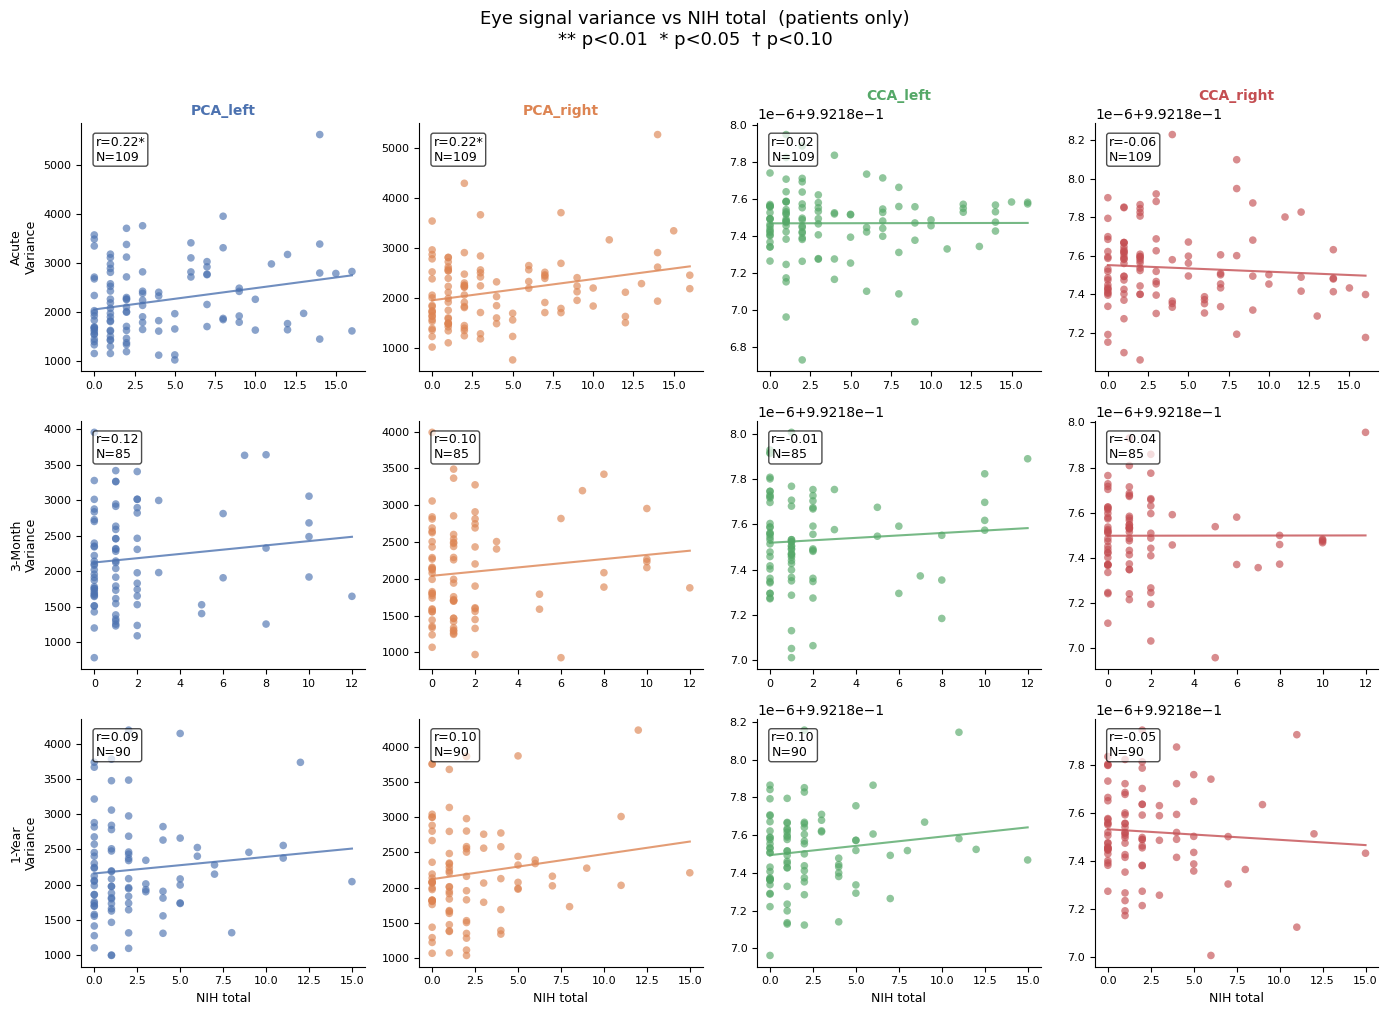

Saved → variance_vs_nih.png


In [38]:
import numpy as np
import pandas as pd
from scipy.stats import spearmanr
import matplotlib.pyplot as plt

# ── 1. COMPUTE VARIANCES ──────────────────────────────────────────
ts_cols = ['PCA_left', 'PCA_right', 'CCA_left', 'CCA_right']
df = stroke_csv[stroke_csv['subj_type'] == 0].copy()   # patients only

for col in ts_cols:
    df[f'var_{col}'] = df[col].apply(
        lambda x: float(np.var(x)) if isinstance(x, (list, np.ndarray)) and len(x) > 0 else np.nan
    )

var_cols  = [f'var_{c}' for c in ts_cols]
print("Non-NaN counts per session:")
print(df.groupby('Session')[var_cols + ['nih_total']].count())

# ── 2. SPEARMAN CORRELATIONS ──────────────────────────────────────
sessions  = ['acute', 'followup2', 'followup']
ses_label = {'acute': 'Acute', 'followup2': '3-Month', 'followup': '1-Year'}

rows = []
for ses in sessions:
    sub = df[df['Session'] == ses]
    for vc in var_cols:
        data = sub[[vc, 'nih_total']].dropna()
        if len(data) < 5: continue
        r, p = spearmanr(data[vc], data['nih_total'])
        rows.append({
            'Session': ses_label[ses], 'Feature': vc.replace('var_',''),
            'r': round(r,3), 'p': round(p,4), 'N': len(data),
            'sig': '**' if p<0.01 else ('*' if p<0.05 else ('†' if p<0.10 else ''))
        })

df_corr = pd.DataFrame(rows)
print("\n=== Spearman r (variance ~ nih_total) ===")
print(df_corr.to_string(index=False))

# ── 3. SCATTER GRID ───────────────────────────────────────────────
colors = {'PCA_left':'#4C72B0','PCA_right':'#DD8452',
          'CCA_left':'#55A868','CCA_right':'#C44E52'}

fig, axes = plt.subplots(3, 4, figsize=(14, 10))
fig.suptitle('Eye signal variance vs NIH total  (patients only)\n'
             '** p<0.01  * p<0.05  † p<0.10', fontsize=13, y=1.01)

for row_i, ses in enumerate(sessions):
    sub = df[df['Session'] == ses]
    for col_i, vc in enumerate(var_cols):
        ax   = axes[row_i, col_i]
        feat = vc.replace('var_', '')
        data = sub[[vc, 'nih_total']].dropna()

        ax.scatter(data['nih_total'], data[vc],
                   color=colors[feat], alpha=0.65, s=30, edgecolors='none')

        if len(data) >= 5:
            m, b = np.polyfit(data['nih_total'], data[vc], 1)
            xline = np.linspace(data['nih_total'].min(), data['nih_total'].max(), 100)
            ax.plot(xline, m*xline+b, color=colors[feat], lw=1.5, alpha=0.8)

        r_row = df_corr[(df_corr['Session']==ses_label[ses]) & (df_corr['Feature']==feat)]
        if len(r_row):
            r_val, sig, n_val = r_row['r'].values[0], r_row['sig'].values[0], r_row['N'].values[0]
            ax.text(0.05, 0.95, f'r={r_val:.2f}{sig}\nN={n_val}',
                    transform=ax.transAxes, va='top', ha='left', fontsize=9,
                    bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.7))

        if row_i == 0:
            ax.set_title(feat, fontsize=10, color=colors[feat], fontweight='bold')
        if col_i == 0:
            ax.set_ylabel(f'{ses_label[ses]}\nVariance', fontsize=9)
        ax.set_xlabel('NIH total' if row_i == 2 else '', fontsize=9)
        ax.tick_params(labelsize=8)
        ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('variance_vs_nih.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → variance_vs_nih.png")

Session                       Eye                  Outcome      r      p   N sig
3-Month Bilateral coherence (raw)      NIHSS Visual Fields  0.319 0.0028  86  **
 1-Year       Var asymmetry (PCA)        Posner RT VF bias -0.310 0.0031  89  **
3-Month         PC1 variance left      NIHSS Visual Fields  0.300 0.0051  86  **
  Acute Bilateral coherence (raw)               NIHSS Gaze -0.261 0.0059 110  **
  Acute       Var asymmetry (PCA)       Posner Acc VF bias  0.245 0.0087 114  **
  Acute         PC1 variance left NIHSS Extinction/Neglect  0.245 0.0100 110   *
  Acute         PC1 variance left        Posner RT VF bias  0.231 0.0157 109   *
 1-Year Bilateral coherence (raw)          BIT Left Misses -0.237 0.0171 101   *
3-Month        PC1 variance right      NIHSS Visual Fields  0.251 0.0196  86   *
 1-Year         PC1 variance left          BIT Left Misses -0.232 0.0198 101   *
  Acute         PC1 variance left              NIHSS Total  0.220 0.0218 109   *
  Acute       Var asymmetry 

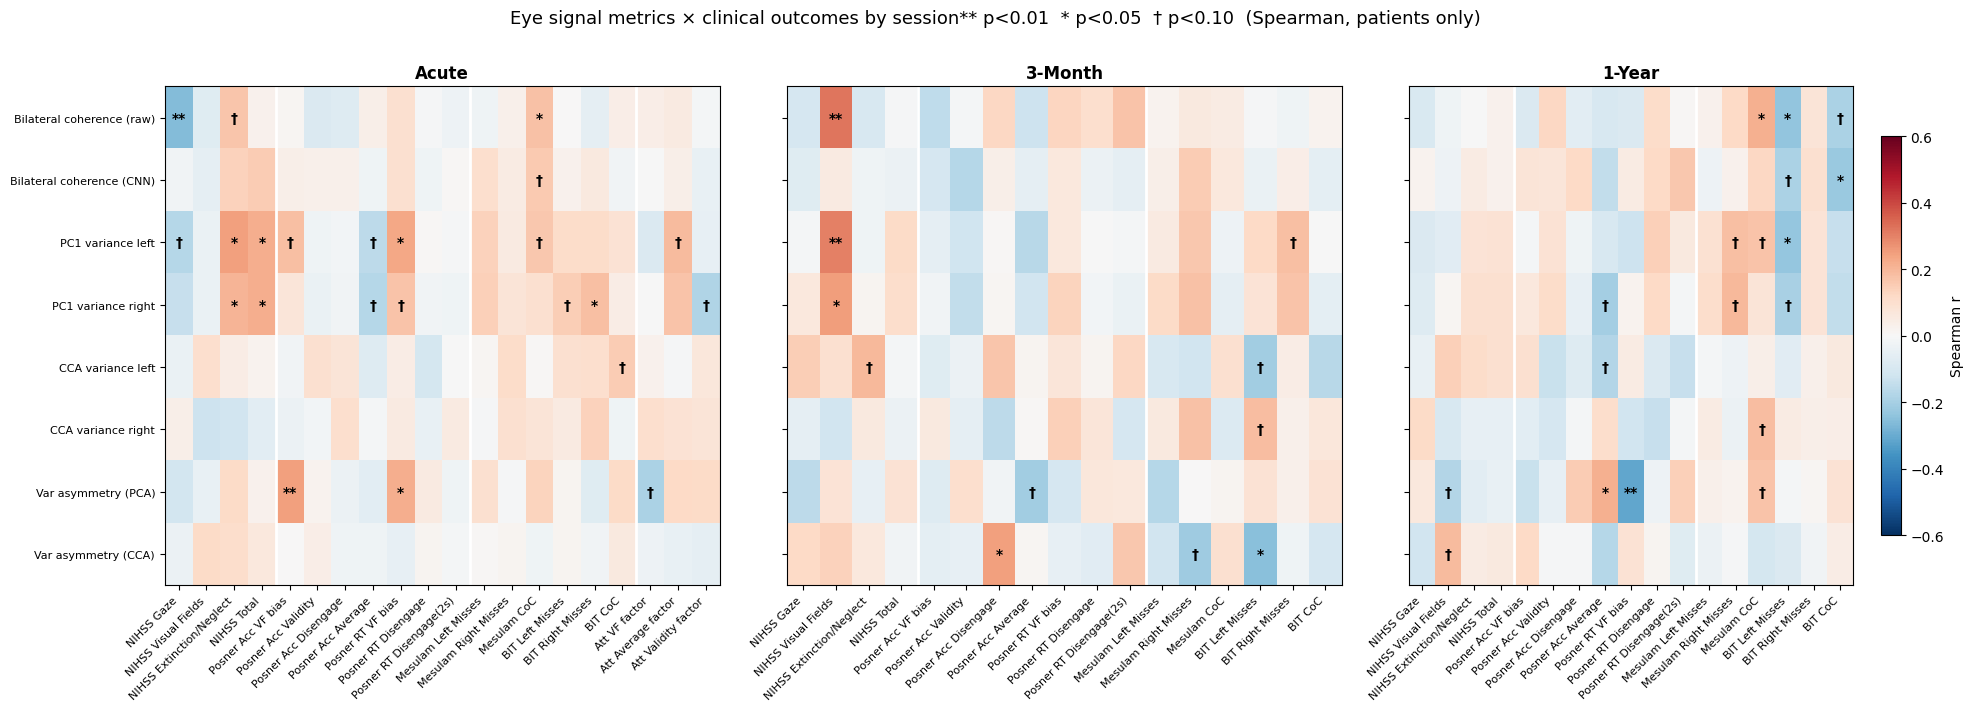

Saved → eye_metrics_outcomes_heatmap.png
Saved → eye_metrics_outcomes_correlations.csv


In [41]:

import numpy as np
import pandas as pd
from scipy.stats import spearmanr
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# ── 1. COMPUTE EYE METRICS FROM TIMESERIES ───────────────────────
ts_cols = ['PCA_left', 'PCA_right', 'CCA_left', 'CCA_right']
df = stroke_csv[stroke_csv['subj_type'] == 0].copy()

for col in ts_cols:
    df[f'var_{col}'] = df[col].apply(
        lambda x: float(np.var(x)) if isinstance(x, (list, np.ndarray)) and len(x) > 0 else np.nan
    )

# Asymmetry: log(var_L / var_R) — positive = L more variable, negative = R
df['var_asym_PCA'] = np.log(df['var_PCA_left']  / (df['var_PCA_right']  + 1e-9))
df['var_asym_CCA'] = np.log(df['var_CCA_left']  / (df['var_CCA_right']  + 1e-9))

# All eye metrics to test
eye_metrics = {
    'PCA_raw':       'Bilateral coherence (raw)',
    'CCA':           'Bilateral coherence (CNN)',
    'var_PCA_left':  'PC1 variance left',
    'var_PCA_right': 'PC1 variance right',
    'var_CCA_left':  'CCA variance left',
    'var_CCA_right': 'CCA variance right',
    'var_asym_PCA':  'Var asymmetry (PCA)',
    'var_asym_CCA':  'Var asymmetry (CCA)',
}

# ── 2. OUTCOME VARIABLES ─────────────────────────────────────────
# NIHSS visual/attention subscores
outcomes_nihss = {
    'nih2':  'NIHSS Gaze',
    'nih3':  'NIHSS Visual Fields',
    'nih11': 'NIHSS Extinction/Neglect',
    'nih_total': 'NIHSS Total',
}

# Posner (spatial attention, validity, disengagement)
outcomes_posner = {
    'pos_acc_vf':         'Posner Acc VF bias',
    'pos_acc_validity':   'Posner Acc Validity',
    'pos_acc_disengage':  'Posner Acc Disengage',
    'pos_acc_avg':        'Posner Acc Average',
    'pos_rt_vf':          'Posner RT VF bias',
    'pos_rt_disengage':   'Posner RT Disengage',
    'pos_sub_disengage':  'Posner RT Disengage(2s)',
}

# Cancellation (neglect)
outcomes_cancel = {
    'mes_l_miss':    'Mesulam Left Misses',
    'mes_r_miss':    'Mesulam Right Misses',
    'mes_coc':       'Mesulam CoC',
    'bit_ltot_miss': 'BIT Left Misses',
    'bit_rtot_miss': 'BIT Right Misses',
    'bit_coc':       'BIT CoC',
}

# Composite factor scores
outcomes_factors = {
    'attention1vf_f':          'Att VF factor',
    'attention2avg_f':         'Att Average factor',
    'attention3val_f':         'Att Validity factor',
    'revised_attvf_factor':    'Att VF (revised)',
    'revised_attave_factor':   'Att Ave (revised)',
    'revised_attvaldis_factor':'Att ValDis (revised)',
}

all_outcomes = {**outcomes_nihss, **outcomes_posner, **outcomes_cancel, **outcomes_factors}

# ── 3. SPEARMAN CORRELATION MATRIX PER SESSION ───────────────────
sessions  = ['acute', 'followup2', 'followup']
ses_label = {'acute': 'Acute', 'followup2': '3-Month', 'followup': '1-Year'}

rows = []
for ses in sessions:
    sub = df[df['Session'] == ses]
    for em, em_label in eye_metrics.items():
        for out, out_label in all_outcomes.items():
            if out not in sub.columns:
                continue
            data = sub[[em, out]].dropna()
            if len(data) < 8:
                continue
            r, p = spearmanr(data[em], data[out])
            rows.append({
                'Session':   ses_label[ses],
                'Eye':       em_label,
                'Outcome':   out_label,
                'r':         round(r, 3),
                'p':         round(p, 4),
                'N':         len(data),
                'sig':       '**' if p < 0.01 else ('*' if p < 0.05 else ('†' if p < 0.10 else ''))
            })

df_corr = pd.DataFrame(rows)
print(df_corr[df_corr['sig'] != ''].sort_values('p').to_string(index=False))
print(f"\nTotal tested: {len(df_corr)}  |  Significant (p<0.05): {(df_corr['p']<0.05).sum()}")

# ── 4. HEATMAP: r values, rows=eye metrics, cols=outcomes, one per session ──
fig, axes = plt.subplots(1, 3, figsize=(20, 7), sharey=True)

dividers = [4, 4+7, 4+7+6]   # boundaries between outcome groups
group_labels = ['NIHSS', 'Posner', 'Cancellation', 'Factors']

for ax, ses in zip(axes, sessions):
    sub_corr = df_corr[df_corr['Session'] == ses_label[ses]]
    pivot = sub_corr.pivot_table(index='Eye', columns='Outcome', values='r', aggfunc='first')
    pivot_p = sub_corr.pivot_table(index='Eye', columns='Outcome', values='p', aggfunc='first')
    pivot_sig = sub_corr.pivot_table(index='Eye', columns='Outcome', values='sig', aggfunc='first')

    # Reorder
    eye_order = list(eye_metrics.values())
    out_order  = [v for v in all_outcomes.values() if v in pivot.columns]
    pivot = pivot.reindex(index=eye_order, columns=out_order)
    pivot_sig = pivot_sig.reindex(index=eye_order, columns=out_order)

    im = ax.imshow(pivot.values.astype(float), aspect='auto',
                   cmap='RdBu_r', vmin=-0.6, vmax=0.6)

    # significance markers
    for i in range(pivot.shape[0]):
        for j in range(pivot.shape[1]):
            val = pivot.values[i, j]
            sig = pivot_sig.values[i, j] if pivot_sig.values[i, j] is not None else ''
            if not np.isnan(float(val)) if isinstance(val, float) else False:
                ax.text(j, i, sig if sig else '', ha='center', va='center',
                        fontsize=10, fontweight='bold', color='k')

    ax.set_xticks(range(len(out_order)))
    ax.set_xticklabels(out_order, rotation=45, ha='right', fontsize=8)
    ax.set_yticks(range(len(eye_order)))
    ax.set_yticklabels(eye_order, fontsize=8)
    ax.set_title(ses_label[ses], fontsize=12, fontweight='bold')

    # group dividers
    cumulative = [0, len(outcomes_nihss), len(outcomes_nihss)+len(outcomes_posner),
                  len(outcomes_nihss)+len(outcomes_posner)+len(outcomes_cancel)]
    for div in cumulative[1:]:
        if div < len(out_order):
            ax.axvline(div - 0.5, color='white', lw=2)

plt.colorbar(im, ax=axes[-1], label="Spearman r", shrink=0.8)
fig.suptitle('Eye signal metrics × clinical outcomes by session'
             '** p<0.01  * p<0.05  † p<0.10  (Spearman, patients only)',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('eye_metrics_outcomes_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → eye_metrics_outcomes_heatmap.png")

df_corr.to_csv('eye_metrics_outcomes_correlations.csv', index=False)
print("Saved → eye_metrics_outcomes_correlations.csv")

In [20]:

import os, glob
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.cross_decomposition import CCA
from sklearn.preprocessing import StandardScaler
from scipy.stats import pearsonr, spearmanr, rankdata
import warnings
warnings.filterwarnings("ignore")

# ════════════════════════════════════════════════════════════════
# CONFIG
# ════════════════════════════════════════════════════════════════
NPZ_DIR  = "/mnt/compneuro/deepmreye_finetuning/stroke_nifti"
N_PCA    = 10    # PCA components before CCA (dimensionality reduction)
N_SPLITS = 20    # CCA cross-val folds
# stroke_csv must already be loaded as a DataFrame
# ════════════════════════════════════════════════════════════════

# ── 0. FILE INDEX ─────────────────────────────────────────────────
all_npzs = glob.glob(os.path.join(NPZ_DIR, "*.npz"))
print(f"NPZ files found: {len(all_npzs)}")

file_index = {}
for f in all_npzs:
    bn   = os.path.basename(f)
    subj = bn.split("_sub-")[0]
    ses_tok = [p for p in bn.split("_") if p.startswith("ses-")]
    if not ses_tok: continue
    session = ses_tok[0].replace("ses-", "")
    stem = bn.replace(".npz", "")
    if   stem.endswith("_left"):  eye = "left"
    elif stem.endswith("_right"): eye = "right"
    else:                          eye = "both"
    file_index[(subj, session, eye)] = f
print(f"Indexed: {len(file_index)} (subj, session, eye) entries")

# ── 1. DATA HELPERS ───────────────────────────────────────────────
def load_patch_matrix(path, n_tp=128):
    d = np.load(path, allow_pickle=True)
    patches = []
    for i in range(n_tp):
        key = f"data_{i}"
        if key not in d: break
        patches.append(d[key].astype(np.float32).flatten())
    return np.vstack(patches)          # (T, V)

def load_labels(path, n_tp=128):
    d = np.load(path, allow_pickle=True)
    labels = []
    for i in range(n_tp):
        key = f"label_{i}"
        if key not in d: break
        labels.append(np.array(d[key], dtype=np.float32).flatten())
    return np.vstack(labels) if labels else None

# ── 2. PCA + CCA ─────────────────────────────────────────────────
def get_pca_scores(X, n_components=N_PCA):
    """Z-score columns, PCA → (scores (T,K), pc1 (T,), var_explained (K,))"""
    Xs     = StandardScaler().fit_transform(X)
    pca    = PCA(n_components=n_components)
    scores = pca.fit_transform(Xs)
    return scores, scores[:, 0], pca.explained_variance_ratio_

def cca_cv_multivariate(scores_L, scores_R, n_splits=N_SPLITS):
    """
    CV-CCA on (T×K) PCA score matrices.
    This is the correct CCA: finds the SHARED spatial component
    across left and right eye patches — not just PC1 correlation.
    Reproduces the CCA=0.7±0.04 metric from the earlier analysis.
    """
    T, sz, rs = scores_L.shape[0], scores_L.shape[0] // n_splits, []
    for i in range(n_splits):
        val = np.arange(i * sz, (i + 1) * sz)
        tr  = np.concatenate([np.arange(0, i * sz), np.arange((i+1)*sz, T)])
        try:
            cca = CCA(n_components=1, max_iter=1000)
            cca.fit(scores_L[tr], scores_R[tr])
            lp, rp = cca.transform(scores_L[val], scores_R[val])
            rs.append(pearsonr(lp[:, 0], rp[:, 0])[0])
        except Exception:
            pass
    return float(np.nanmean(rs)), float(np.nanstd(rs))

# ── 3. FEATURE DICT ───────────────────────────────────────────────
def eye_features(pc_L, pc_R, scores_L, scores_R, evar_L, evar_R):
    f = {}
    # ─ PC1-based features ─
    f["pca_mean_L"]    = float(np.mean(pc_L))
    f["pca_mean_R"]    = float(np.mean(pc_R))
    f["pca_var_L"]     = float(np.var(pc_L))
    f["pca_var_R"]     = float(np.var(pc_R))
    f["pca_RL_r"]      = float(pearsonr(pc_L, pc_R)[0])
    pooled = float(np.std(np.concatenate([pc_L, pc_R]))) + 1e-9
    f["pca_RL_asym"]   = float(abs(np.mean(pc_L) - np.mean(pc_R)) / pooled)
    f["pca_var_asym"]  = float(np.log((np.var(pc_L)+1e-9)/(np.var(pc_R)+1e-9)))
    xcorr = np.correlate(pc_L - pc_L.mean(), pc_R - pc_R.mean(), mode="full")
    xcorr /= (len(pc_L) * (pc_L.std()+1e-9) * (pc_R.std()+1e-9))
    lags = np.arange(-len(pc_L)+1, len(pc_L))
    f["pca_xcorr_peak"] = float(xcorr.max())
    f["pca_xcorr_lag"]  = int(lags[xcorr.argmax()])
    # ─ Variance explained ─
    f["pca_var_explained_L"] = float(evar_L[0])
    f["pca_var_explained_R"] = float(evar_R[0])
    f["pca_cumvar_L"]        = float(evar_L.sum())
    f["pca_cumvar_R"]        = float(evar_R.sum())
    # ─ Per-PC correlation and asymmetry (PC1–PC3) ─
    for k in range(min(3, scores_L.shape[1])):
        f[f"pca_RL_r_pc{k+1}"] = float(pearsonr(scores_L[:,k], scores_R[:,k])[0])
        f[f"pca_var_asym_pc{k+1}"] = float(
            np.log((np.var(scores_L[:,k])+1e-9)/(np.var(scores_R[:,k])+1e-9)))
    return f

# ── 4. CLINICAL DATA ──────────────────────────────────────────────
df_clin = stroke_csv.copy()
vis_cols = ["visual_er___1","visual_er___2","visual_er___3",
            "visual_acute_ad___1","visual_acute_ad___2","visual_acute_ad___3"]
for c in vis_cols:
    if c not in df_clin.columns: df_clin[c] = 0
df_clin["any_visual"] = df_clin[vis_cols].fillna(0).max(axis=1).astype(bool)
df_clin["field_cut"]  = df_clin[["visual_er___1","visual_acute_ad___1"]].fillna(0).max(axis=1).astype(bool)
df_clin["diplopia"]   = df_clin[["visual_er___2","visual_acute_ad___2"]].fillna(0).max(axis=1).astype(bool)
df_clin["other_vis"]  = df_clin[["visual_er___3","visual_acute_ad___3"]].fillna(0).max(axis=1).astype(bool)
for col in ["nih2","nih3","nih11"]:
    if col not in df_clin.columns: df_clin[col] = np.nan
df_clin["nih_visual_sum"] = df_clin[["nih2","nih3","nih11"]].fillna(0).sum(axis=1)

# ── 5. MAIN LOOP ──────────────────────────────────────────────────
records, skipped = [], []

for _, row in df_clin.iterrows():
    subj_id = str(row["ID"])
    session  = str(row.get("Session", "acute"))
    key_L   = (subj_id, session, "left")
    key_R   = (subj_id, session, "right")

    if key_L not in file_index or key_R not in file_index:
        skipped.append(f"MISSING  {subj_id:12s}  {session}")
        continue

    try:
        X_L = load_patch_matrix(file_index[key_L])
        X_R = load_patch_matrix(file_index[key_R])

        scores_L, pc_L, evar_L = get_pca_scores(X_L, N_PCA)
        scores_R, pc_R, evar_R = get_pca_scores(X_R, N_PCA)

        cca_r_mean, cca_r_std = cca_cv_multivariate(scores_L, scores_R)

        feats = eye_features(pc_L, pc_R, scores_L, scores_R, evar_L, evar_R)
        feats["cca_RL_r_mean"] = cca_r_mean   # TRUE shared spatial component r
        feats["cca_RL_r_std"]  = cca_r_std

        # Gaze label features
        try:
            lbl_L = load_labels(file_index[key_L])
            lbl_R = load_labels(file_index[key_R])
            if lbl_L is not None and lbl_L.shape[1] >= 2:
                feats["gaze_x_mean_L"]  = float(np.mean(lbl_L[:,0]))
                feats["gaze_x_mean_R"]  = float(np.mean(lbl_R[:,0]))
                feats["gaze_y_mean_L"]  = float(np.mean(lbl_L[:,1]))
                feats["gaze_y_mean_R"]  = float(np.mean(lbl_R[:,1]))
                feats["gaze_x_asym"]    = float(np.mean(lbl_L[:,0]) - np.mean(lbl_R[:,0]))
                feats["gaze_y_asym"]    = float(np.mean(lbl_L[:,1]) - np.mean(lbl_R[:,1]))
                feats["gaze_x_var_L"]   = float(np.var(lbl_L[:,0]))
                feats["gaze_x_var_R"]   = float(np.var(lbl_R[:,0]))
                feats["gaze_y_var_L"]   = float(np.var(lbl_L[:,1]))
                feats["gaze_y_var_R"]   = float(np.var(lbl_R[:,1]))
                feats["gaze_x_RL_r"]    = float(pearsonr(lbl_L[:,0], lbl_R[:,0])[0])
                feats["gaze_y_RL_r"]    = float(pearsonr(lbl_L[:,1], lbl_R[:,1])[0])
        except Exception:
            pass

        feats.update({
            "ID": subj_id, "Session": session,
            "subj_type":         row.get("subj_type"),
            "nih_total":         row.get("nih_total"),
            "nih2_gaze":         row.get("nih2"),
            "nih3_vf":           row.get("nih3"),
            "nih11_neglect":     row.get("nih11"),
            "nih_visual_sum":    row.get("nih_visual_sum"),
            "lesion_size":       row.get("lesion_size"),
            "lesion_volume_mm3": row.get("lesion_volume_mm3"),
            "lesion_side":       row.get("lesion_side"),
            "lesion_site":       row.get("lesion_site"),
            "any_visual":        row.get("any_visual"),
            "field_cut":         row.get("field_cut"),
            "diplopia":          row.get("diplopia"),
            "other_vis":         row.get("other_vis"),
        })
        records.append(feats)
        if len(records) % 25 == 0:
            print(f"  ✓ {len(records):3d} sessions processed...")

    except Exception as e:
        skipped.append(f"ERROR    {subj_id:12s}  {session}: {e}")

print(f"\n✓ Extracted : {len(records)} sessions")
print(f"  Skipped   : {len(skipped)}")
for s in skipped[:15]: print(f"    {s}")

df_feat = pd.DataFrame(records)
df_feat.to_csv("eye_features_all_sessions.csv", index=False)
print(f"\nSaved → eye_features_all_sessions.csv  {df_feat.shape}")

# ── 6. CORRELATIONS ───────────────────────────────────────────────
eye_cols     = [c for c in df_feat.columns if c.startswith(("pca_","cca_","gaze_"))]
outcome_vars = ["nih_total","nih2_gaze","nih3_vf","nih11_neglect",
                "nih_visual_sum","lesion_size","lesion_volume_mm3"]

corr_rows = []
for feat in eye_cols:
    for outcome in outcome_vars:
        sub = df_feat[["Session", feat, outcome]].dropna()
        for ses in ["acute","followup2","followup","all"]:
            data = sub if ses == "all" else sub[sub["Session"] == ses]
            if len(data) < 5: continue
            try:
                r_sp, p_sp = spearmanr(data[feat], data[outcome])
                r_pe, p_pe = pearsonr(data[feat], data[outcome])
                corr_rows.append({
                    "Feature": feat, "Outcome": outcome, "Session": ses,
                    "Spearman_r": round(r_sp,3), "Spearman_p": round(p_sp,4),
                    "Pearson_r":  round(r_pe,3), "Pearson_p":  round(p_pe,4),
                    "N": len(data)
                })
            except Exception:
                pass

if not corr_rows:
    print("\n⚠  No correlations. Check NaN counts:")
    for v in outcome_vars:
        if v in df_feat: print(f"  {v}: {df_feat[v].isna().sum()} NaN / {len(df_feat)}")
else:
    df_corr = pd.DataFrame(corr_rows).sort_values("Spearman_p").reset_index(drop=True)
    n = len(df_corr)
    ranks = rankdata(df_corr["Spearman_p"].values)
    df_corr["p_FDR"]   = np.minimum(1.0, df_corr["Spearman_p"].values * n / ranks)
    df_corr["sig_FDR"] = df_corr["p_FDR"] < 0.05
    df_corr.to_csv("eye_stroke_correlations.csv", index=False)

    sig = df_corr[df_corr["sig_FDR"]]
    print(f"\n{'='*70}")
    print(f"Significant (FDR q<0.05): {len(sig)}")
    print(f"{'='*70}")
    if len(sig):
        print(sig[["Feature","Outcome","Session","Spearman_r","Spearman_p","p_FDR","N"]].to_string(index=False))
    else:
        print("None survive FDR. Top 20 uncorrected:")
        print(df_corr[["Feature","Outcome","Session","Spearman_r","Spearman_p","N"]].head(20).to_string(index=False))
    print("\nSaved → eye_stroke_correlations.csv")

NPZ files found: 1254
Indexed: 1254 (subj, session, eye) entries
  ✓  25 sessions processed...
  ✓  50 sessions processed...
  ✓  75 sessions processed...
  ✓ 100 sessions processed...
  ✓ 125 sessions processed...
  ✓ 150 sessions processed...
  ✓ 175 sessions processed...
  ✓ 200 sessions processed...
  ✓ 225 sessions processed...
  ✓ 250 sessions processed...
  ✓ 275 sessions processed...
  ✓ 300 sessions processed...
  ✓ 325 sessions processed...
  ✓ 350 sessions processed...
  ✓ 375 sessions processed...

✓ Extracted : 384 sessions
  Skipped   : 2
    MISSING  PAT105        followup2
    MISSING  PAT133        acute

Saved → eye_features_all_sessions.csv  (384, 49)

Significant (FDR q<0.05): 0
None survive FDR. Top 20 uncorrected:
            Feature           Outcome   Session  Spearman_r  Spearman_p   N
pca_var_explained_R lesion_volume_mm3       all       0.243      0.0000 278
pca_var_explained_R       lesion_size       all       0.243      0.0000 275
          pca_var_R lesion

In [19]:
pwd

'/mnt/compneuro/deepmreye_finetuning/Cemal'

In [17]:
# Paste this quick diagnostic BEFORE the main pipeline
import os, glob, numpy as np

NPZ_DIR = '/mnt/compneuro/deepmreye_finetuning/stroke_nifti'
npzs = glob.glob(os.path.join(NPZ_DIR, '**/*.npz'), recursive=True)
print(f"Found: {len(npzs)} npz files")
print("First 5:", npzs[:5])
if npzs:
    d = np.load(npzs[0], allow_pickle=True)
    print("Keys:", list(d.keys()))

Found: 1254 npz files
First 5: ['/mnt/compneuro/deepmreye_finetuning/stroke_nifti/CON001_sub-CON001_ses-control_task-rest_run-0_bold.npz', '/mnt/compneuro/deepmreye_finetuning/stroke_nifti/CON001_sub-CON001_ses-control_task-rest_run-0_bold_left.npz', '/mnt/compneuro/deepmreye_finetuning/stroke_nifti/CON001_sub-CON001_ses-control_task-rest_run-0_bold_right.npz', '/mnt/compneuro/deepmreye_finetuning/stroke_nifti/CON002_sub-CON002_ses-control2_task-rest_run-0_bold.npz', '/mnt/compneuro/deepmreye_finetuning/stroke_nifti/CON002_sub-CON002_ses-control2_task-rest_run-0_bold_left.npz']
Keys: ['data_0', 'label_0', 'identifier_0', 'data_1', 'label_1', 'identifier_1', 'data_2', 'label_2', 'identifier_2', 'data_3', 'label_3', 'identifier_3', 'data_4', 'label_4', 'identifier_4', 'data_5', 'label_5', 'identifier_5', 'data_6', 'label_6', 'identifier_6', 'data_7', 'label_7', 'identifier_7', 'data_8', 'label_8', 'identifier_8', 'data_9', 'label_9', 'identifier_9', 'data_10', 'label_10', 'identifier_10'